# Import Library 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
#from apyori import apriori
import os
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules, apriori
import matplotlib.pyplot as plt 

C:\Users\Varad\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Import Data

In [2]:
data=pd.read_csv(r"C:\Users\Varad\Downloads\Market-Basket-Analysis-master\Market-Basket-Analysis-master\Data\store_data.csv")
data.head()

,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
0,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5177 entries, 0 to 5176
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shrimp             5177 non-null   str    
 1   almonds            3953 non-null   str    
 2   avocado            2998 non-null   str    
 3   vegetables mix     2312 non-null   str    
 4   green grapes       1771 non-null   str    
 5   whole weat flour   1319 non-null   str    
 6   yams               981 non-null    str    
 7   cottage cheese     707 non-null    str    
 8   energy drink       477 non-null    str    
 9   tomato juice       290 non-null    str    
 10  low fat yogurt     189 non-null    str    
 11  green tea          113 non-null    str    
 12  honey              70 non-null     str    
 13  salad              39 non-null     str    
 14  mineral water      20 non-null     str    
 15  salmon             7 non-null      str    
 16  antioxydant juice  3 non-null      

C:\Users\Varad\AppData\Local\Temp\ipykernel_15368\3832448932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=data['shrimp'],


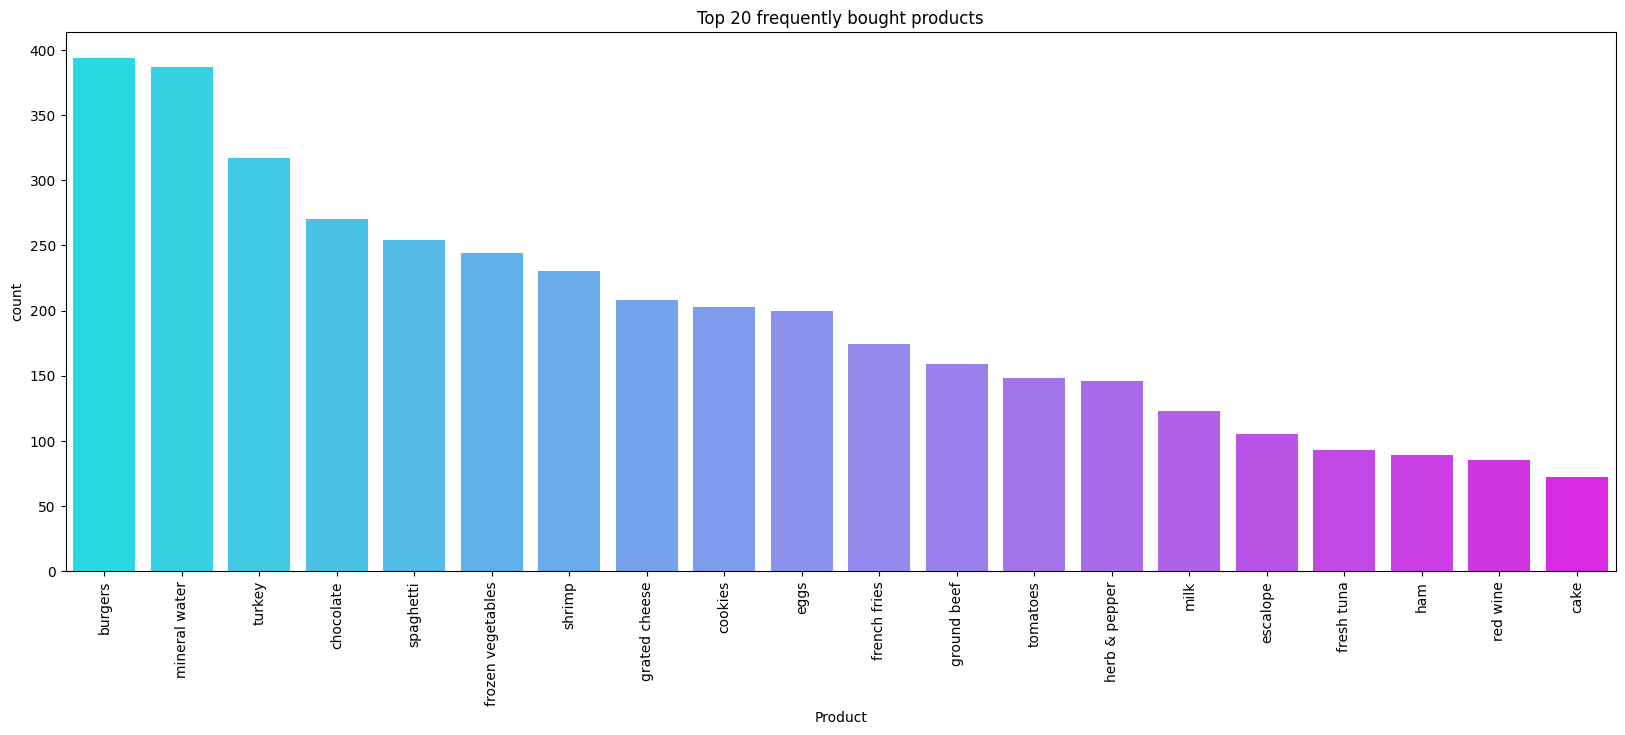

In [4]:
#Top 20 frequently buying items by customer
plt.rcParams['figure.figsize']=20,7
sns.countplot(data=data, x=data['shrimp'],
             order = data['shrimp'].value_counts().head(20).index,
             palette='cool')
plt.xticks(rotation=90)
plt.xlabel('Product')
plt.title('Top 20 frequently bought products')
plt.show()

In [5]:
#let's create a list of list of transaction
records = []
for i in range(len(data)):
    transaction = []
    for j in range(len(data.columns)):
        if pd.notna(data.values[i, j]):
            transaction.append(str(data.values[i, j]))
    records.append(transaction)

In [6]:
records

[['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'],
 ['low fat yogurt'],
 ['whole wheat pasta', 'french fries'],
 ['soup', 'light cream', 'shallot'],
 ['frozen vegetables', 'spaghetti', 'green tea'],
 ['french fries'],
 ['eggs', 'pet food'],
 ['cookies'],
 ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil'],
 ['spaghetti', 'champagne', 'cookies'],
 ['mineral water', 'salmon'],
 ['mineral water'],
 ['shrimp',
  'chocolate',
  'chicken',
  'honey',
  'oil',
  'cooking oil',
  'low fat yogurt'],
 ['turkey', 'eggs'],
 ['turkey',
  'fresh tuna',
  'tomatoes',
  'spaghetti',
  'mineral water',
  'black tea',
  'salmon',
  'eggs',
  'chicken',
  'extra dark chocolate'],
 ['meatballs', 'milk', 'honey', 'french fries', 'protein bar'],
 ['red wine', 'shrimp', 'pasta', 'pepper', 'eggs', 'chocolate', 'shampoo'],
 ['rice', 'sparkling water'],
 ['spaghetti', 'mineral water', 'ham', 'body spray',

#Let's analyze the no. of items wrt each transaction
counts = [len(abc) for abc in records]
print(f'50 percent of the transactions are having items below or equal to {np.quantile(counts, .5)} only')
print(f'particular transaction having a maximum of {np.quantile(counts, 1)} items in it')

In [7]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
onehot = te.fit_transform(records)
onehot = pd.DataFrame(onehot, columns = te.columns_)

Using Transactionencoder we can transform this dataset into a logical data frame.
Each column represents an item and each row represent a record or a transaction for one purchase.

In [8]:
onehot.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
#Shape of encoded onehot dataset
print(f'No.of Transection data: {onehot.shape[0]} rows and {onehot.shape[1]} unique Product(Columns)')

No.of Transection data: 5177 rows and 120 unique Product(Columns)


In [29]:
from mlxtend.frequent_patterns import apriori, fpmax, fpgrowth

frequent_itemsets = apriori(onehot, min_support=0.001,use_colnames=True, max_len=3,verbose=1)

frequent_itemsets

Processing 235089 combinations | Sampling itemset size 3


,support,itemsets
0,0.019316,frozenset({almonds})
1,0.007726,frozenset({antioxydant juice})
2,0.003863,frozenset({asparagus})
3,0.035735,frozenset({avocado})
4,0.003863,frozenset({babies food})
...,...,...
5631,0.001545,"frozenset({spaghetti, vegetables mix, tomatoes})"
5632,0.001545,"frozenset({spaghetti, whole wheat pasta, tomat..."
5633,0.003091,"frozenset({whole wheat rice, spaghetti, tomato..."
5634,0.002318,"frozenset({whole wheat rice, spaghetti, turkey})"


In [30]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)  
rules = rules.sort_values('lift', ascending=False)

In [31]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
12889,frozenset({shallot}),"frozenset({low fat yogurt, cookies})",0.008692,0.005409,0.001545,0.177778,32.869841,1.0,0.001498,1.209638,0.978079,0.123077,0.173307,0.231746
12884,"frozenset({low fat yogurt, cookies})",frozenset({shallot}),0.005409,0.008692,0.001545,0.285714,32.869841,1.0,0.001498,1.387831,0.974849,0.123077,0.279451,0.231746
16071,frozenset({pasta}),"frozenset({escalope, mushroom cream sauce})",0.013908,0.005795,0.002511,0.180556,31.157870,1.0,0.002431,1.213267,0.981557,0.146067,0.175779,0.306944
16066,"frozenset({escalope, mushroom cream sauce})",frozenset({pasta}),0.005795,0.013908,0.002511,0.433333,31.157870,1.0,0.002431,1.740163,0.973547,0.146067,0.425341,0.306944
16070,frozenset({mushroom cream sauce}),"frozenset({escalope, pasta})",0.018737,0.004443,0.002511,0.134021,30.166293,1.0,0.002428,1.149632,0.985312,0.121495,0.130156,0.349619


In [32]:
Output = round(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']],3)  # rounding off number by 2 digit after decimal 

Output.head(10)

,antecedents,consequents,support,confidence,lift
12889,frozenset({shallot}),"frozenset({low fat yogurt, cookies})",0.002,0.178,32.870
12884,"frozenset({low fat yogurt, cookies})",frozenset({shallot}),0.002,0.286,32.870
16071,frozenset({pasta}),"frozenset({escalope, mushroom cream sauce})",0.003,0.181,31.158
16066,"frozenset({escalope, mushroom cream sauce})",frozenset({pasta}),0.003,0.433,31.158
16070,frozenset({mushroom cream sauce}),"frozenset({escalope, pasta})",0.003,0.134,30.166
16067,"frozenset({escalope, pasta})",frozenset({mushroom cream sauce}),0.003,0.565,30.166
17627,"frozenset({honey, fresh tuna})",frozenset({fromage blanc}),0.001,0.318,25.342
17630,frozenset({fromage blanc}),"frozenset({honey, fresh tuna})",0.001,0.108,25.342
17031,frozenset({mushroom cream sauce}),"frozenset({french fries, pasta})",0.001,0.062,21.348
17026,"frozenset({french fries, pasta})",frozenset({mushroom cream sauce}),0.001,0.400,21.348


In [33]:
targeted_rules = Output[Output['consequents'] == {'shallot'}].copy()
targeted_rules

,antecedents,consequents,support,confidence,lift
12884,"frozenset({low fat yogurt, cookies})",frozenset({shallot}),0.002,0.286,32.870
12862,"frozenset({green tea, cookies})",frozenset({shallot}),0.002,0.113,12.963
12813,"frozenset({cookies, french fries})",frozenset({shallot}),0.001,0.089,10.194
16813,"frozenset({low fat yogurt, french fries})",frozenset({shallot}),0.001,0.086,9.861
16535,"frozenset({green tea, french fries})",frozenset({shallot}),0.001,0.039,4.453
1328,frozenset({cookies}),frozenset({shallot}),0.003,0.030,3.438
3369,frozenset({salmon}),frozenset({shallot}),0.001,0.027,3.068
2892,frozenset({low fat yogurt}),frozenset({shallot}),0.002,0.025,2.869
1729,frozenset({escalope}),frozenset({shallot}),0.002,0.025,2.827
2452,frozenset({green tea}),frozenset({shallot}),0.003,0.019,2.146


In [34]:
targeted_rules = Output[Output['consequents'] == {'cookies'}].copy()
targeted_rules

,antecedents,consequents,support,confidence,lift
12885,"frozenset({low fat yogurt, shallot})",frozenset({cookies}),0.002,0.800,9.521
12863,"frozenset({green tea, shallot})",frozenset({cookies}),0.002,0.615,7.324
12814,"frozenset({shallot, french fries})",frozenset({cookies}),0.001,0.538,6.408
1329,frozenset({shallot}),frozenset({cookies}),0.003,0.289,3.438
12778,"frozenset({escalope, pancakes})",frozenset({cookies}),0.001,0.214,2.550
12837,"frozenset({whole wheat rice, french fries})",frozenset({cookies}),0.002,0.211,2.506
5714,"frozenset({green tea, burgers})",frozenset({cookies}),0.004,0.207,2.458
6990,"frozenset({french fries, butter})",frozenset({cookies}),0.001,0.189,2.252
12789,"frozenset({green tea, french fries})",frozenset({cookies}),0.006,0.187,2.227
12875,"frozenset({green tea, whole wheat rice})",frozenset({cookies}),0.002,0.186,2.214


In [35]:
filtered_rules = targeted_rules[(targeted_rules['confidence'] > 0.1) &
                                (targeted_rules['lift'] > 1.00)]
filtered_rules

,antecedents,consequents,support,confidence,lift
12885,"frozenset({low fat yogurt, shallot})",frozenset({cookies}),0.002,0.800,9.521
12863,"frozenset({green tea, shallot})",frozenset({cookies}),0.002,0.615,7.324
12814,"frozenset({shallot, french fries})",frozenset({cookies}),0.001,0.538,6.408
1329,frozenset({shallot}),frozenset({cookies}),0.003,0.289,3.438
12778,"frozenset({escalope, pancakes})",frozenset({cookies}),0.001,0.214,2.550
12837,"frozenset({whole wheat rice, french fries})",frozenset({cookies}),0.002,0.211,2.506
5714,"frozenset({green tea, burgers})",frozenset({cookies}),0.004,0.207,2.458
6990,"frozenset({french fries, butter})",frozenset({cookies}),0.001,0.189,2.252
12789,"frozenset({green tea, french fries})",frozenset({cookies}),0.006,0.187,2.227
12875,"frozenset({green tea, whole wheat rice})",frozenset({cookies}),0.002,0.186,2.214


# Finished

support_table = filtered_rules.pivot(index='consequents', columns='antecedents', values='lift')
support_table

sns.heatmap(support_table)

Output.to_csv("demo.csv")